In [ ]:
import pandas as pd
import numpy as np

hours = list(range(24)) * 7
days  = [d for d in range(7) for _ in range(24)]
base_usage = [95,80,72,68,74,140,310,480,430,390,360,380,
              420,400,370,350,390,440,500,480,420,320,200,130]
base_temp  = [28,27,27,26,27,29,32,35,36,37,38,38,
              39,39,38,37,37,38,39,39,38,36,33,30]

df = pd.DataFrame({
    'hour':      hours,
    'day':       days,
    'usage_kwh': [base_usage[h] * (0.75 if d >= 5 else 1.0) for h, d in zip(hours, days)],
    'temp_c':    base_temp * 7
})

# --- TIME FEATURES ---
df['is_weekend']  = (df['day'] >= 5).astype(int)
df['is_peak_hour']= df['hour'].isin(range(17, 22)).astype(int)
df['month']       = 6

# --- CYCLICAL ENCODING ---
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['day_sin']  = np.sin(2 * np.pi * df['day']  / 7)
df['day_cos']  = np.cos(2 * np.pi * df['day']  / 7)

# --- LAG FEATURES ---
df['usage_lag_1h']  = df['usage_kwh'].shift(1)
df['usage_lag_24h'] = df['usage_kwh'].shift(24)

# --- ROLLING WINDOW FEATURES ---
df['rolling_mean_6h']  = df['usage_kwh'].rolling(6).mean()
df['rolling_mean_24h'] = df['usage_kwh'].rolling(24).mean()
df['rolling_std_24h']  = df['usage_kwh'].rolling(24).std()

# --- DOMAIN FEATURES ---
df['cooling_degree'] = (df['temp_c'] - 24).clip(lower=0)
df['temp_squared']   = df['temp_c'] ** 2

# Drop NaN rows created by lag/rolling
df = df.dropna().reset_index(drop=True)

print(f"Dataset shape: {df.shape}")
print(f"\nFeature columns ({len(df.columns)-1} features + 1 label):")
for col in df.columns:
    tag = " ← label (y)" if col == 'usage_kwh' else ""
    print(f"  {col}{tag}")

# Correlation ranking
corr = df.corr()['usage_kwh'].drop('usage_kwh').abs().sort_values(ascending=False)
print("\nFeature importance (correlation with usage):")
print(corr.round(2))

Dataset shape: (144, 18)

Feature columns (17 features + 1 label):
  hour
  day
  usage_kwh ← label (y)
  temp_c
  is_weekend
  is_peak_hour
  month
  hour_sin
  hour_cos
  day_sin
  day_cos
  usage_lag_1h
  usage_lag_24h
  rolling_mean_6h
  rolling_mean_24h
  rolling_std_24h
  cooling_degree
  temp_squared

Feature importance (correlation with usage):
usage_lag_24h       0.98
cooling_degree      0.90
temp_c              0.90
temp_squared        0.90
usage_lag_1h        0.90
hour_cos            0.67
rolling_mean_6h     0.66
hour                0.49
is_peak_hour        0.43
hour_sin            0.38
is_weekend          0.25
day                 0.21
day_sin             0.21
rolling_mean_24h    0.16
rolling_std_24h     0.15
day_cos             0.11
month                NaN
Name: usage_kwh, dtype: float64


   hour  usage_kwh  temperature_c
0     0        120             28
1     1         98             27
2     2         85             27
3     3         75             26
4     4         90             27
5     5        180             29
6     6        340             32
7     7        480             35
###############
   hour  usage_kwh  temperature_c
6     6        340             32
7     7        480             35


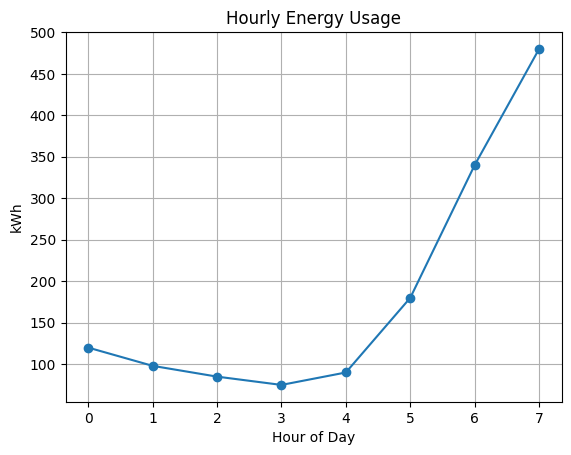

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Create a DataFrame from a dictionary
data = {
    "hour": [0, 1, 2, 3, 4, 5, 6, 7],
    "usage_kwh": [120, 98, 85, 75, 90, 180, 340, 480],
    "temperature_c": [28, 27, 27, 26, 27, 29, 32, 35]
}

df = pd.DataFrame(data)
print(df)
''' print(df.shape)       # (8, 3) — 8 rows, 3 columns
print(df.dtypes)      # shows each column's data type
 '''

# Select one column (returns a Series)
df["usage_kwh"]

# Select multiple columns
df[["hour", "usage_kwh"]]

# Filter rows — only peak hours (usage > 300)
peak_hours = df[df["usage_kwh"] > 300]
print("###############")
print(peak_hours)

# Add a new column
df["is_peak"] = df["usage_kwh"] > 300

df["usage_kwh"].mean()    # average usage
df["usage_kwh"].max()     # peak usage
df["usage_kwh"].sum()     # total day's usage
df["usage_kwh"].std()     # how much usage varies

# Correlation — does temp predict usage?
df["usage_kwh"].corr(df["temperature_c"])
# Output near 1.0 means strong relationship!

plt.plot(df["hour"], df["usage_kwh"], marker="o")
plt.title("Hourly Energy Usage")
plt.xlabel("Hour of Day")
plt.ylabel("kWh")
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

hours = list(range(24)) * 7
days  = [d for d in range(7) for _ in range(24)]
base_usage = [95,80,72,68,74,140,310,480,430,390,360,380,
              420,400,370,350,390,440,500,480,420,320,200,130]
base_temp  = [28,27,27,26,27,29,32,35,36,37,38,38,
              39,39,38,37,37,38,39,39,38,36,33,30]

df = pd.DataFrame({
    'hour':      hours,
    'day':       days,
    'usage_kwh': [base_usage[h] * (0.75 if d >= 5 else 1.0) for h, d in zip(hours, days)],
    'temp_c':    base_temp * 7
})

# --- TIME FEATURES ---
df['is_weekend']  = (df['day'] >= 5).astype(int)
df['is_peak_hour']= df['hour'].isin(range(17, 22)).astype(int)
df['month']       = 6

# --- CYCLICAL ENCODING ---
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['day_sin']  = np.sin(2 * np.pi * df['day']  / 7)
df['day_cos']  = np.cos(2 * np.pi * df['day']  / 7)

# --- LAG FEATURES ---
df['usage_lag_1h']  = df['usage_kwh'].shift(1)
df['usage_lag_24h'] = df['usage_kwh'].shift(24)

# --- ROLLING WINDOW FEATURES ---
df['rolling_mean_6h']  = df['usage_kwh'].rolling(6).mean()
df['rolling_mean_24h'] = df['usage_kwh'].rolling(24).mean()
df['rolling_std_24h']  = df['usage_kwh'].rolling(24).std()

# --- DOMAIN FEATURES ---
df['cooling_degree'] = (df['temp_c'] - 24).clip(lower=0)
df['temp_squared']   = df['temp_c'] ** 2

# Drop NaN rows created by lag/rolling
df = df.dropna().reset_index(drop=True)

plt.figure(figsize=(10, 6))
sns.scatterplot(x='temp_c', y='usage_kwh', data=df, hue='is_peak_hour', palette='viridis', size='usage_kwh', sizes=(20, 400), alpha=0.7)
plt.title('Usage (kWh) vs. Temperature (C)')
plt.xlabel('Temperature (C)')
plt.ylabel('Usage (kWh)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

NameError: name 'df' is not defined

<Figure size 1000x600 with 0 Axes>

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(df['usage_kwh'], model='additive', period=24)
result.plot()  # shows trend, seasonal, and residual as separate charts

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(df['usage_kwh'], lags=48)   # look for spikes at 24, 48
plot_pacf(df['usage_kwh'], lags=48)  # tells you direct vs indirect effects

In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['usage_kwh'])
p_value = result[1]

if p_value < 0.05:
    print("Stationary — good to go")
else:
    print("Non-stationary — apply differencing")
    df['usage_diff'] = df['usage_kwh'].diff()  # subtract previous value

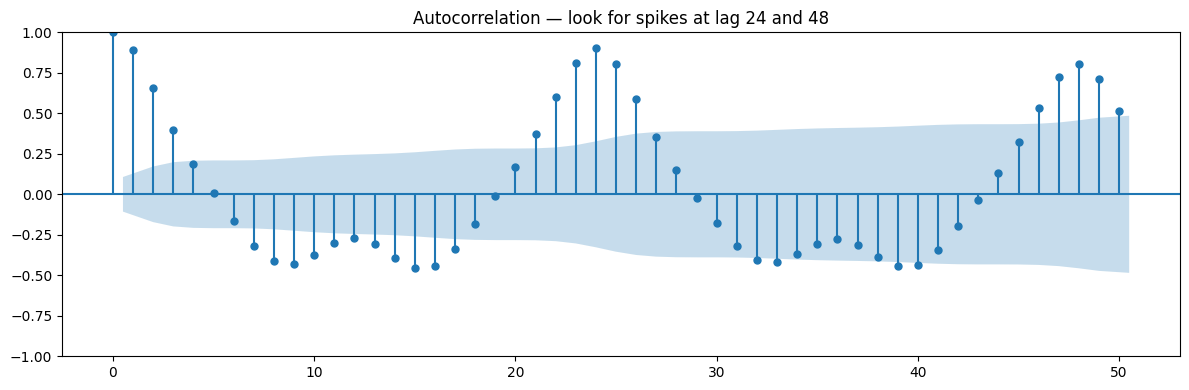

ADF statistic: -2.666
p-value: 0.0800
Non-stationary — consider differencing

Train: 268 rows (11 days)
Test:  68 rows (2 days)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller

BASE = [95,80,72,68,74,140,310,480,430,390,360,380,
        420,400,370,350,390,440,500,480,420,320,200,130]

rows = []
for d in range(14):
    is_we = d % 7 >= 5
    for h in range(24):
        noise = np.sin(d*5+h)*11 + np.cos(d*2+h*3)*8
        rows.append({
            'ds': pd.Timestamp('2024-06-01') + pd.Timedelta(hours=d*24+h),
            'usage_kwh': max(40, BASE[h] * (0.77 if is_we else 1.0) + d*3.5 + noise)
        })

df = pd.DataFrame(rows).set_index('ds')

# --- DECOMPOSITION ---
result = seasonal_decompose(df['usage_kwh'], model='additive', period=24)
result.plot()
plt.suptitle('Seasonal Decomposition', y=1.02)
plt.tight_layout()
plt.show()

# --- ACF ---
fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(df['usage_kwh'], lags=50, ax=ax)
ax.set_title('Autocorrelation — look for spikes at lag 24 and 48')
plt.tight_layout()
plt.show()

# --- STATIONARITY TEST ---
stat, p, *_ = adfuller(df['usage_kwh'])
print(f"ADF statistic: {stat:.3f}")
print(f"p-value: {p:.4f}")
print("Stationary" if p < 0.05 else "Non-stationary — consider differencing")

# --- CORRECT CHRONOLOGICAL SPLIT ---
split = int(len(df) * 0.8)
train = df.iloc[:split]
test  = df.iloc[split:]
print(f"\nTrain: {len(train)} rows ({len(train)//24} days)")
print(f"Test:  {len(test)} rows ({len(test)//24} days)")

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

BASE = [95,80,72,68,74,140,310,480,430,390,360,380,
        420,400,370,350,390,440,500,480,420,320,200,130]
TEMP = [28,27,27,26,27,29,32,35,36,37,38,38,
        39,39,38,37,37,38,39,39,38,36,33,30]

rows = []
for d in range(21):
    is_we = d % 7 >= 5
    for h in range(24):
        noise = np.sin(d*5+h)*11 + np.cos(d*2+h*3)*8
        rows.append({
            'usage': max(40, BASE[h]*(0.77 if is_we else 1.0) + d*3.5 + noise),
            'temp':  TEMP[h],
            'hour_sin': np.sin(2*np.pi*h/24),
            'hour_cos': np.cos(2*np.pi*h/24),
            'is_weekend': int(is_we)
        })

df = pd.DataFrame(rows)

# Scale all features to 0-1 range (crucial for neural networks)
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df)

# Build sequences — each sample = 24 hours of history
WINDOW = 24
FEATURES = df.shape[1]
X, y = [], []
for i in range(WINDOW, len(scaled)):
    X.append(scaled[i-WINDOW:i])   # 24 timesteps × 5 features
    y.append(scaled[i, 0])         # predict usage (column 0)
X, y = np.array(X), np.array(y)    # shapes: (N, 24, 5) and (N,)

# Chronological split
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"X_train shape: {X_train.shape}")   # (samples, 24, 5)
print(f"X_test shape:  {X_test.shape}")

# Build the LSTM
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(WINDOW, FEATURES)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

# Train with early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# Evaluate
preds_scaled = model.predict(X_test).flatten()

# Inverse scale — back to kWh
dummy = np.zeros((len(preds_scaled), FEATURES))
dummy[:, 0] = preds_scaled
preds_kwh = scaler.inverse_transform(dummy)[:, 0]

dummy2 = np.zeros((len(y_test), FEATURES))
dummy2[:, 0] = y_test
actual_kwh = scaler.inverse_transform(dummy2)[:, 0]

print(f"\nLSTM Test MAE: {mean_absolute_error(actual_kwh, preds_kwh):.1f} kWh")

X_train shape: (384, 24, 5)
X_test shape:  (96, 24, 5)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,881 (120.63 KB)

 Trainable params: 30,881 (120.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 204ms/step - loss: 0.1608 - mae: 0.3307 - val_loss: 0.0631 - val_mae: 0.2128
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0766 - mae: 0.2401 - val_loss: 0.0828 - val_mae: 0.2650
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0583 - mae: 0.2074 - val_loss: 0.0374 - val_mae: 0.1605
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0374 - mae: 0.1594 - val_loss: 0.0239 - val_mae: 0.1343
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0332 - mae: 0.1431 - val_loss: 0.0222 - val_mae: 0.1257
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0347 - mae: 0.1520 - val_loss: 0.0229 - val_mae: 0.1131
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0278 - mae: 0.1357 - val_loss: 0.0189 - val_mae: 0.1012
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0226 - mae: 0.1179 - val_loss: 0.0162 - val_mae: 0.0947
Epoch 9/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - 

/tmp/ipykernel_1613/276870532.py:15: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df_raw = pd.read_csv(url, sep=';', parse_dates={'datetime': ['Date','Time']},
/tmp/ipykernel_1613/276870532.py:15: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df_raw = pd.read_csv(url, sep=';', parse_dates={'datetime': ['Date','Time']},
/tmp/ipykernel_1613/276870532.py:15: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_raw = pd.read_csv(url, sep=';', parse_dates={'datetime': ['Date','Time']},


Raw shape: (2075259, 7)
After cleaning: (34570, 1)
        usage_kw
count  34570.000
mean       1.086
std        0.888
min        0.124
25%        0.342
50%        0.804
75%        1.574
max        5.562

Feature-engineered shape: (34402, 17)
Train: (27521, 13), Test: (6881, 13)


/tmp/ipykernel_1613/276870532.py:26: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df = df.resample('H').mean()
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
XGBoost     MAE=0.2988 kW  RMSE=0.4304 kW  MAPE=38.9%
LSTM        MAE=0.3430 kW  RMSE=0.4914 kW  MAPE=46.0%
Ensemble    MAE=0.3100 kW  RMSE=0.4437 kW  MAPE=41.3%


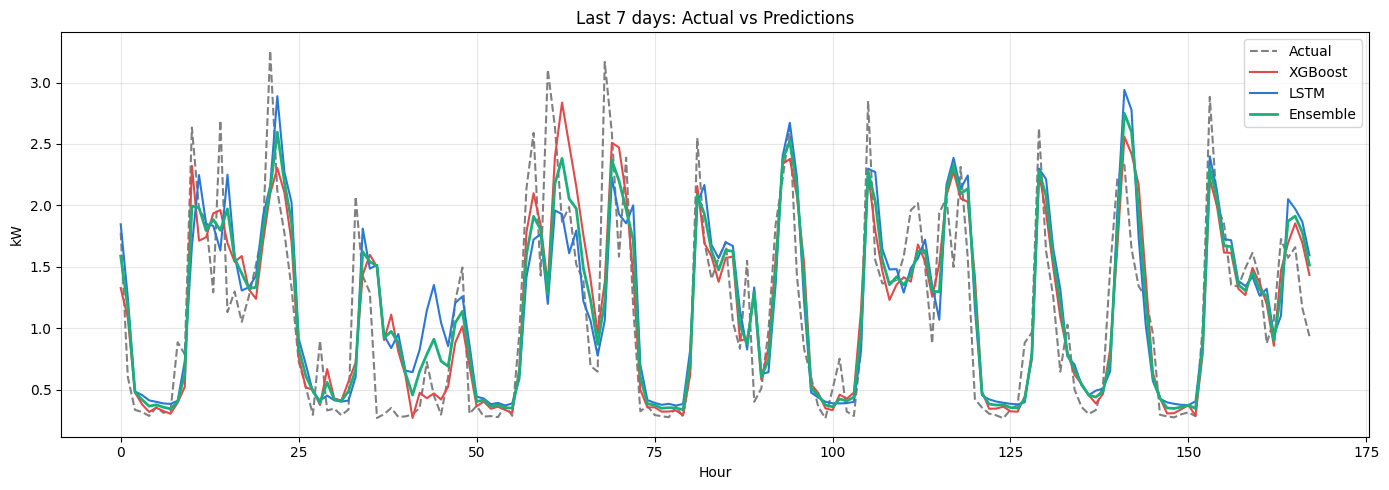

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# ── 1. LOAD ──────────────────────────────────────────────────────────────
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00235/household_power_consumption.zip"
df_raw = pd.read_csv(url, sep=';', parse_dates={'datetime': ['Date','Time']},
                     infer_datetime_format=True, low_memory=False, na_values='?')
df_raw.set_index('datetime', inplace=True)
print(f"Raw shape: {df_raw.shape}")

# ── 2. CLEAN ─────────────────────────────────────────────────────────────
df = df_raw[['Global_active_power']].copy()
df.columns = ['usage_kw']
df = df.astype(float)

# Resample 1-min → 1-hour
df = df.resample('H').mean()

# Fill short gaps with forward fill, then backward fill for any remaining
df['usage_kw'] = df['usage_kw'].ffill().bfill()

# Remove extreme outliers (> 5 std from mean)
mean, std = df['usage_kw'].mean(), df['usage_kw'].std()
df = df[(df['usage_kw'] > mean - 5*std) & (df['usage_kw'] < mean + 5*std)]
print(f"After cleaning: {df.shape}")
print(df.describe().round(3))

# ── 3. FEATURE ENGINEERING ────────────────────────────────────────────────
df['hour']        = df.index.hour
df['day_of_week'] = df.index.dayofweek
df['month']       = df.index.month
df['is_weekend']  = (df['day_of_week'] >= 5).astype(int)
df['is_peak']     = df['hour'].isin(range(17, 22)).astype(int)

df['hour_sin']    = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos']    = np.cos(2 * np.pi * df['hour'] / 24)
df['dow_sin']     = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos']     = np.cos(2 * np.pi * df['day_of_week'] / 7)
df['month_sin']   = np.sin(2 * np.pi * df['month'] / 12)

df['lag_1h']      = df['usage_kw'].shift(1)
df['lag_24h']     = df['usage_kw'].shift(24)
df['lag_168h']    = df['usage_kw'].shift(168)

df['roll_mean_6h']  = df['usage_kw'].rolling(6).mean()
df['roll_mean_24h'] = df['usage_kw'].rolling(24).mean()
df['roll_std_24h']  = df['usage_kw'].rolling(24).std()

df = df.dropna().reset_index(drop=True)
print(f"\nFeature-engineered shape: {df.shape}")

# ── 4. SPLIT ─────────────────────────────────────────────────────────────
FEATURES = ['hour_sin','hour_cos','dow_sin','dow_cos','month_sin',
            'is_weekend','is_peak','lag_1h','lag_24h','lag_168h',
            'roll_mean_6h','roll_mean_24h','roll_std_24h']
TARGET = 'usage_kw'

split = int(len(df) * 0.8)
X_train = df[FEATURES].iloc[:split].values
X_test  = df[FEATURES].iloc[split:].values
y_train = df[TARGET].iloc[:split].values
y_test  = df[TARGET].iloc[split:].values

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# ── 5a. XGBOOST ───────────────────────────────────────────────────────────
xgb_model = xgb.XGBRegressor(
    n_estimators=500, learning_rate=0.05,
    max_depth=6, subsample=0.8, random_state=42, verbosity=0
)
xgb_model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)], verbose=False)
xgb_preds = xgb_model.predict(X_test)

# ── 5b. LSTM ──────────────────────────────────────────────────────────────
WINDOW = 24
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df[[TARGET] + FEATURES])

X_seq, y_seq = [], []
for i in range(WINDOW, len(scaled)):
    X_seq.append(scaled[i-WINDOW:i, 1:])
    y_seq.append(scaled[i, 0])
X_seq, y_seq = np.array(X_seq), np.array(y_seq)

split_seq = int(len(X_seq) * 0.8)
Xl_train, Xl_test = X_seq[:split_seq], X_seq[split_seq:]
yl_train, yl_test = y_seq[:split_seq], y_seq[split_seq:]

lstm = Sequential([
    LSTM(64, return_sequences=True, input_shape=(WINDOW, len(FEATURES))),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])
lstm.compile(optimizer='adam', loss='mse')
lstm.fit(Xl_train, yl_train, validation_split=0.1,
         epochs=50, batch_size=32, verbose=0,
         callbacks=[EarlyStopping(patience=8, restore_best_weights=True)])

raw_preds = lstm.predict(Xl_test).flatten()
dummy = np.zeros((len(raw_preds), len(FEATURES)+1))
dummy[:, 0] = raw_preds
lstm_preds = scaler.inverse_transform(dummy)[:, 0]

# Align lengths for comparison
n = min(len(xgb_preds), len(lstm_preds))
actual   = y_test[-n:]
xgb_p    = xgb_preds[-n:]
lstm_p   = lstm_preds[-n:]
ensemble = (xgb_p + lstm_p) / 2

# ── 6. EVALUATE ───────────────────────────────────────────────────────────
for name, preds in [('XGBoost', xgb_p), ('LSTM', lstm_p), ('Ensemble', ensemble)]:
    mae  = mean_absolute_error(actual, preds)
    rmse = np.sqrt(mean_squared_error(actual, preds))
    mape = np.mean(np.abs((actual - preds) / actual)) * 100
    print(f"{name:10s}  MAE={mae:.4f} kW  RMSE={rmse:.4f} kW  MAPE={mape:.1f}%")

# Plot last 7 days
plt.figure(figsize=(14, 5))
last = 168
plt.plot(actual[-last:],   label='Actual', color='gray',    linewidth=1.5, linestyle='--')
plt.plot(xgb_p[-last:],    label='XGBoost', color='#e34948', linewidth=1.5)
plt.plot(lstm_p[-last:],   label='LSTM',    color='#2a78d6', linewidth=1.5)
plt.plot(ensemble[-last:], label='Ensemble',color='#1baf7a', linewidth=2)
plt.legend()
plt.title('Last 7 days: Actual vs Predictions')
plt.xlabel('Hour')
plt.ylabel('kW')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [3]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
import warnings
warnings.filterwarnings('ignore')

# ── XGBoost hyperparameter search ─────────────────────────────────────────
param_dist = {
    'n_estimators':       [200, 300, 500, 700],
    'learning_rate':      [0.01, 0.03, 0.05, 0.1],
    'max_depth':          [3, 4, 5, 6, 7],
    'subsample':          [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree':   [0.6, 0.7, 0.8, 1.0],
    'min_child_weight':   [1, 3, 5],
}

# Walk-forward cross-validation — respects time order
tscv = TimeSeriesSplit(n_splits=5)

search = RandomizedSearchCV(
    xgb.XGBRegressor(verbosity=0, random_state=42),
    param_dist,
    n_iter=30,              # test 30 random combinations
    cv=tscv,
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1               # use all CPU cores
)
search.fit(X_train, y_train)

print("Best params:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nCV MAE: {-search.best_score_:.4f} kW")

# Retrain on full train set with best params
best_xgb = search.best_estimator_
final_preds = best_xgb.predict(X_test)
print(f"Test MAE: {mean_absolute_error(y_test, final_preds):.4f} kW")

Best params:
  subsample: 0.9
  n_estimators: 300
  min_child_weight: 5
  max_depth: 7
  learning_rate: 0.03
  colsample_bytree: 0.8

CV MAE: 0.3432 kW
Test MAE: 0.2969 kW


In [5]:
# ── LSTM hyperparameter search — manual loop ───────────────────────────────
configs = [
    {'units': 64,  'window': 24, 'dropout': 0.2, 'lr': 0.001},
    {'units': 128, 'window': 24, 'dropout': 0.2, 'lr': 0.001},
    {'units': 64,  'window': 36, 'dropout': 0.2, 'lr': 0.001},
    {'units': 64,  'window': 24, 'dropout': 0.3, 'lr': 0.001},
    {'units': 64,  'window': 24, 'dropout': 0.2, 'lr': 0.0005},
]

results = []
for cfg in configs:
    W = cfg['window']
    X_s, y_s = [], []
    for i in range(W, len(scaled)):
        X_s.append(scaled[i-W:i, 1:])
        y_s.append(scaled[i, 0])
    X_s, y_s = np.array(X_s), np.array(y_s)
    sp = int(len(X_s)*0.8)
    Xl_tr, Xl_te = X_s[:sp], X_s[sp:]
    yl_tr, yl_te = y_s[:sp], y_s[sp:]

    m = Sequential([
        LSTM(cfg['units'], return_sequences=True, input_shape=(W, len(FEATURES))),
        Dropout(cfg['dropout']),
        LSTM(cfg['units']//2),
        Dropout(cfg['dropout']),
        Dense(1)
    ])
    m.compile(optimizer=tf.keras.optimizers.Adam(cfg['lr']), loss='mse')
    m.fit(Xl_tr, yl_tr, epochs=50, batch_size=32, verbose=0,
          validation_split=0.1,
          callbacks=[EarlyStopping(patience=8, restore_best_weights=True)])

    raw = m.predict(Xl_te, verbose=0).flatten()
    dummy = np.zeros((len(raw), len(FEATURES)+1))
    dummy[:, 0] = raw
    preds_kw = scaler.inverse_transform(dummy)[:, 0]
    actual_kw = y_test[-len(preds_kw):]
    mae = mean_absolute_error(actual_kw, preds_kw)
    results.append({**cfg, 'mae': mae})
    print(f"units={cfg['units']} window={W} dropout={cfg['dropout']} lr={cfg['lr']} → MAE={mae:.4f}")

best_cfg = min(results, key=lambda x: x['mae'])
print(f"\nBest config: {best_cfg}")

units=64 window=24 dropout=0.2 lr=0.001 → MAE=0.3658
units=128 window=24 dropout=0.2 lr=0.001 → MAE=0.3479
units=64 window=36 dropout=0.2 lr=0.001 → MAE=0.3419
units=64 window=24 dropout=0.3 lr=0.001 → MAE=0.3424
units=64 window=24 dropout=0.2 lr=0.0005 → MAE=0.3416

Best config: {'units': 64, 'window': 24, 'dropout': 0.2, 'lr': 0.0005, 'mae': 0.3416093643165003}


In [6]:
# ── Walk-forward validation for final model assessment ────────────────────
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)
fold_maes = []

for fold, (tr_idx, te_idx) in enumerate(tscv.split(X_train)):
    Xf_tr, Xf_te = X_train[tr_idx], X_train[te_idx]
    yf_tr, yf_te = y_train[tr_idx], y_train[te_idx]
    m = xgb.XGBRegressor(**search.best_params_, verbosity=0, random_state=42)
    m.fit(Xf_tr, yf_tr)
    mae = mean_absolute_error(yf_te, m.predict(Xf_te))
    fold_maes.append(mae)
    print(f"Fold {fold+1}: MAE = {mae:.4f}")

print(f"\nMean MAE: {np.mean(fold_maes):.4f} ± {np.std(fold_maes):.4f} kW")

Fold 1: MAE = 0.4022
Fold 2: MAE = 0.3775
Fold 3: MAE = 0.3101
Fold 4: MAE = 0.3056
Fold 5: MAE = 0.3206

Mean MAE: 0.3432 ± 0.0392 kW


In [7]:
import pickle
import os

os.makedirs('model', exist_ok=True)
os.makedirs('data',  exist_ok=True)

# Save XGBoost model
with open('model/xgb_model.pkl', 'wb') as f:
    pickle.dump(best_xgb, f)

# Save scaler (needed to inverse-transform LSTM predictions)
with open('model/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save processed data for the dashboard charts
df.to_csv('data/processed.csv', index=False)

print("Models and data saved!")


Models and data saved!


# New Section

In [ ]:
from google.colab import drive
drive.mount('/content/drive')